Contexte

Le défaut de paiement constitue un enjeu majeur pour les institutions financières. Lorsqu'une banque accorde une carte de crédit à un client, elle prend le risque que celui-ci ne rembourse pas les sommes empruntées. Une mauvaise évaluation de ce risque peut entraîner des pertes financières importantes. Il est donc essentiel de disposer d'outils capables d'identifier les clients susceptibles de faire défaut avant que celui-ci ne survienne.

Problématique

Dans ce projet, nous nous intéressons à la prédiction du défaut de paiement de clients détenteurs d'une carte de crédit. À partir d'informations démographiques, financières et comportementales, l'objectif est de déterminer si un client effectuera ou non un défaut de paiement le mois suivant.

Objectif

Ce problème est formulé comme une tâche de classification binaire supervisée. L'objectif est de comparer plusieurs modèles de machine learning afin d'identifier celui offrant les meilleures performances prédictives pour ce problème.

In [48]:
# WARNINGS
import warnings
warnings.filterwarnings('ignore')

# NUMPY
import numpy as np

# STATS
import scipy.stats as stats
from scipy.stats import norm, skew

# MATPLOTLIB
import matplotlib as mlp
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight') 

# PANDAS
import pandas as pd 
pd.set_option("display.max_rows", None, "display.max_columns", None) 

# SEABORN
import seaborn as sns

# SCIKIT-LEARN: SELECTION DE VARIABLES

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# SCIKIT-LEARN: PRE-PROCESSING
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder # Encodage des variables catégorielles ordinales
from sklearn.preprocessing import LabelBinarizer, OneHotEncoder # Encodage des variables catégorielles nominales
from sklearn.preprocessing import StandardScaler # Normalisation des variables numériques
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer # Imputation
from sklearn.impute import KNNImputer 

# SCIKIT-LEARN: MODELES
from sklearn.linear_model import LogisticRegression

# SCIKIT-LEARN: VALIDATION CROISEE + OPTIMISATION
from sklearn.model_selection import train_test_split # Séparer en données train et test
from sklearn.model_selection import cross_val_score # Validation croisée pour comparison entre modèles
from sklearn.model_selection import validation_curve # Courbe de validation : visulaisr des scores lors du choix d'un hyper-paramètre
from sklearn.model_selection import GridSearchCV # Tester plusieurs hyper-paramètres
from sklearn.model_selection import learning_curve # Courbe d'apprentissage : visualisation des scores du train et du validation sets en fonction des quanitiés des données
 
## EVALUATION
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# SCHIKIT-LEARN: PIPELINE AND TRANSFORMATEURll
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer


Analyse Exploratoire de Données (AED)

In [49]:
! pip install xlrd

In [50]:
data = pd.read_excel('data/default of credit card clients.xls', header=1)
df = data.copy()

In [51]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [52]:
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [53]:
df.shape

(30000, 25)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [55]:
df.columns.values

array(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
       'PAY_AMT6', 'default payment next month'], dtype=object)

In [56]:

# Résumé statistique des variables
print(df.dtypes)
df.describe()

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Description des variables

- Limit_Bal : montant du crédit accordé, variable continue
- sex: 1 (homme), 2 (femme)
- Education : 1 = études supérieures ; 2 = études universitaires ; 3 = études secondaires ; 4 = autres
- Marriage : 1 = marié(e) ; 2 = célibataire ; 3 = autres
- Age : en années, variable continue 
- Pay_0 à Pay_6 : état du remboursement des paiements mensuels antérieurs ( de Septembre à Avril 2005) => : -1 = paiement à l’échéance ; 1 = retard de paiement d’un mois ; 2 = retard de paiement de deux mois
- Bill_Amt1 à Bill_Amt5 : montant de la facture en $ => variable continue
- Pay_Amt1 à Pay_Amt6 : montant du paiement précédent en $ => variable continue
- default payment next month : variable cible vaut 1(oui) et 0(non) => defaut de paiement, variable binaire discrète. 

Description de la variable d'intérêt

In [57]:
df['default payment next month'].describe()


,default payment next month
count,30000.000000
mean,0.221200
std,0.415062
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [58]:
target = df['default payment next month']
var_explicatives = df.drop('default payment next month',axis=1)

In [59]:
# Vérifier l'existence des duplications d'exemples 
duplicate_df = df[df.duplicated()]
duplicate_df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month


Text(0.5, 1.0, 'Matrice de corrélation')

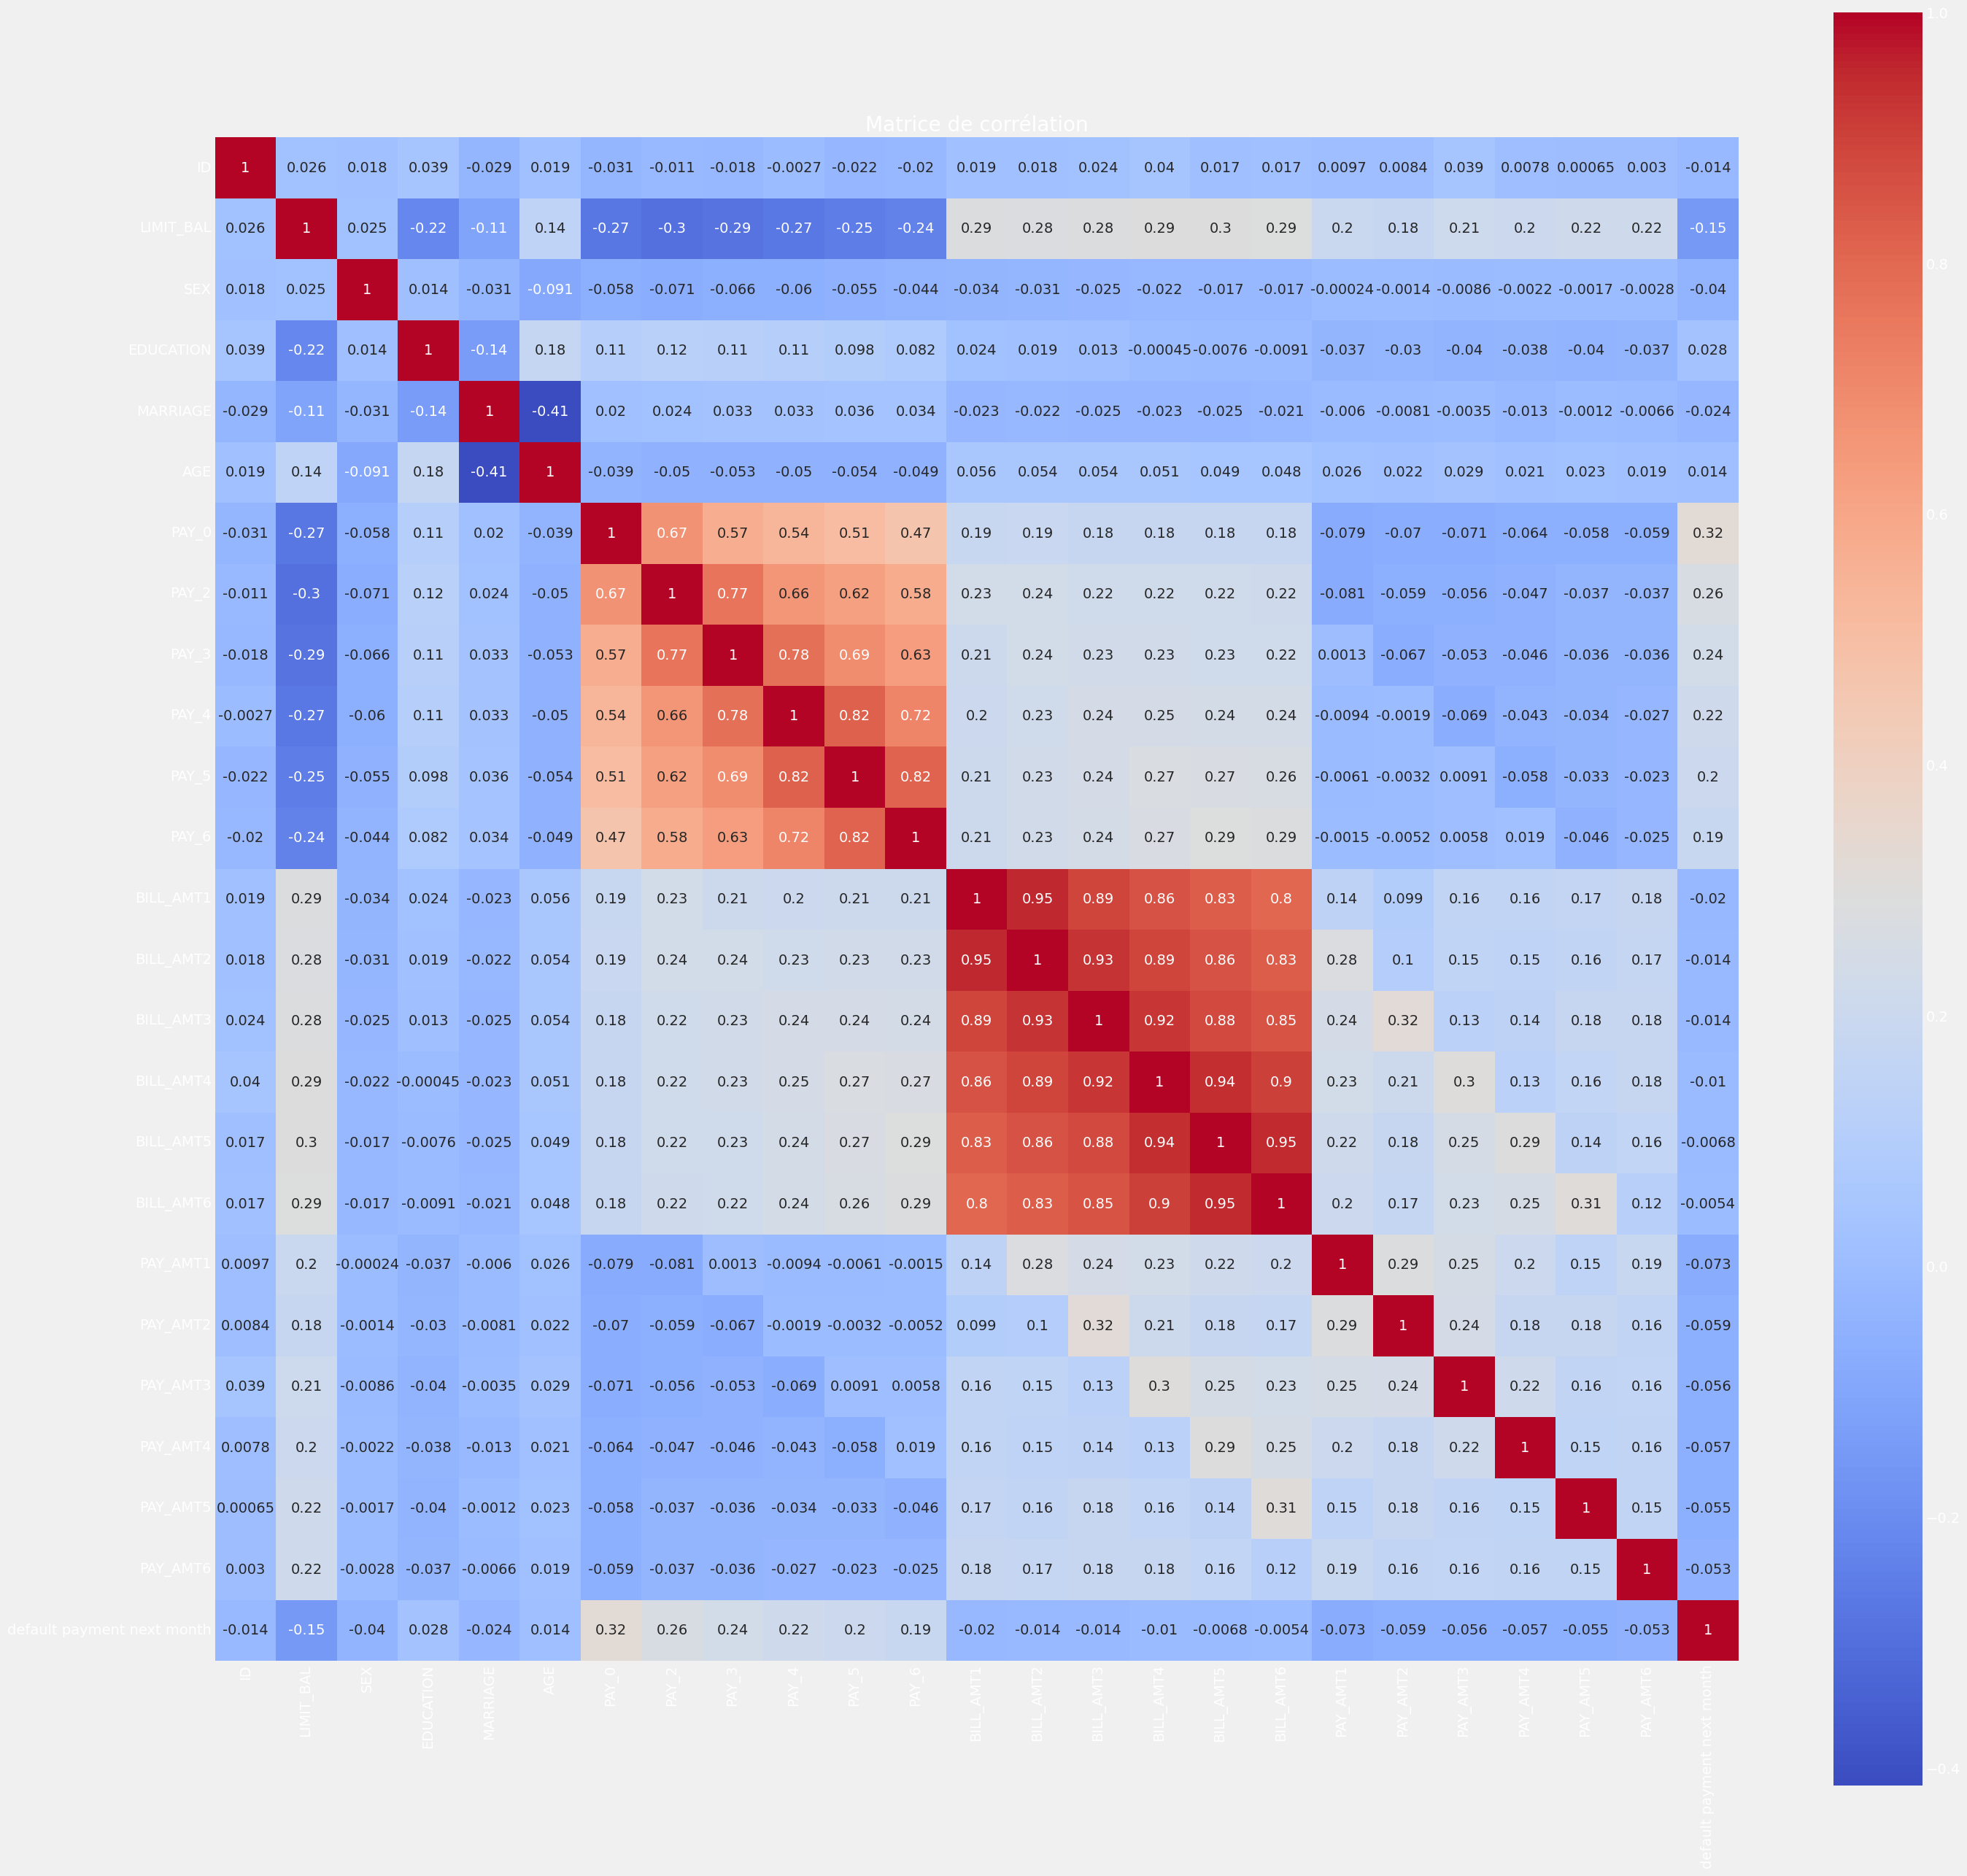

In [60]:
# Matrice de corrélation
corrmat = df.corr(numeric_only=True)
plt.figure(figsize=(30,30))
sns.heatmap(corrmat, cmap='coolwarm', square=True,annot = True)
plt.title("Matrice de corrélation")


### Interprétation
L'analyse montre une très forte corrélation (entre 0.80 et 0.95) entre les montants des factures (BILL_AMT1 à BILL_AMT6). Cela indique que les montants facturés sur des mois consécutifs évoluent de manière similaire et traduisent le niveau d'endettement du client. De plus ces variables Bill_AMT sont aussi corrélées avec les variables Pay_AMT car les clients bénéficiant d'une limite de crédit élevée réalisent souvent des dépenses plus importantes.

De même, les statuts de paiement (PAY_0 à PAY_6) sont fortement corrélés entre eux (entre 0.47 et 0.82), indiquant qu'un client en retard de paiement un mois donné a tendance à l'être aussi les mois qui suivent. Enfin, on observe une corrélation négative de -0.41 entre l'âge et le statut marital, confirmant logiquement que les clients plus âgés sont plus souvent mariés.

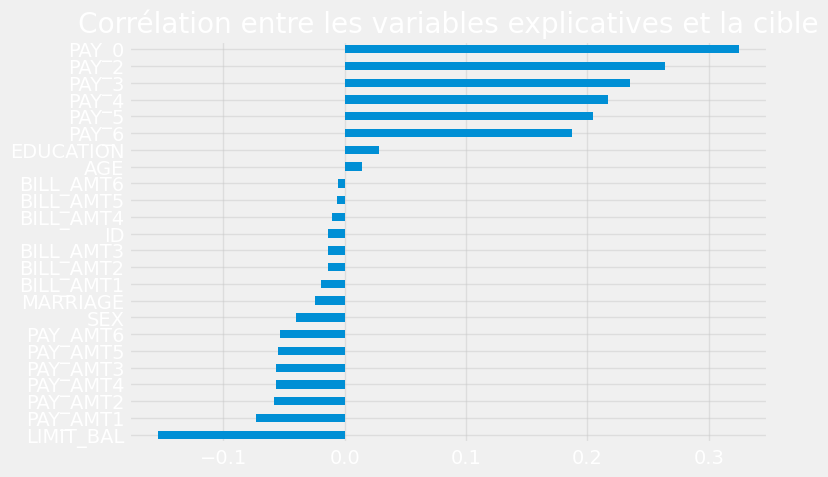

In [61]:
plt.rcParams["figure.figsize"] = (8, 5)
corrmat['default payment next month'].sort_values(ascending=True)[:-1].plot(kind='barh')
plt.title("Corrélation entre les variables explicatives et la cible")
plt.tight_layout()
plt.show()

Les variables d'historique de paiement (PAY_0 à PAY_6) sont les plus prédictives, avec une corrélation positive qui s'accentue à mesure qu'on se rapproche de l'échéance, passant de 0.19 en avril (PAY_6) à 0.32 en septembre (PAY_0). 

À l'inverse, la limite de crédit (LIMIT_BAL) présente une corrélation négative de -0.15, ce qui montre que les clients ayant de gros crédits font statistiquement moins de défauts. Pour finir, les variables socio-démographiques comme le sexe, l'âge, l'éducation ou le mariage ont des corrélations proches de zéro, ce qui signifie qu'elles n'ont pas d'impact linéaire direct sur le risque de défaut.

Visualisation variables numériques vs cible

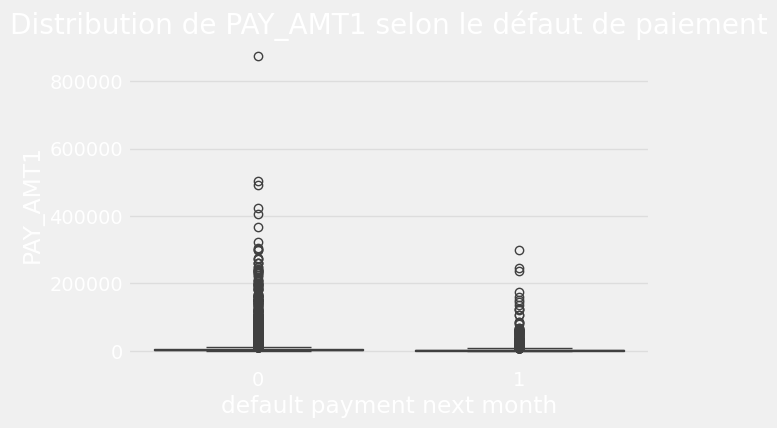

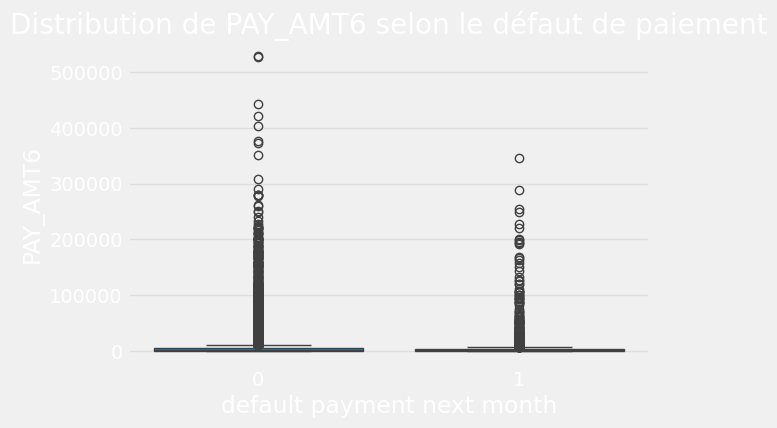

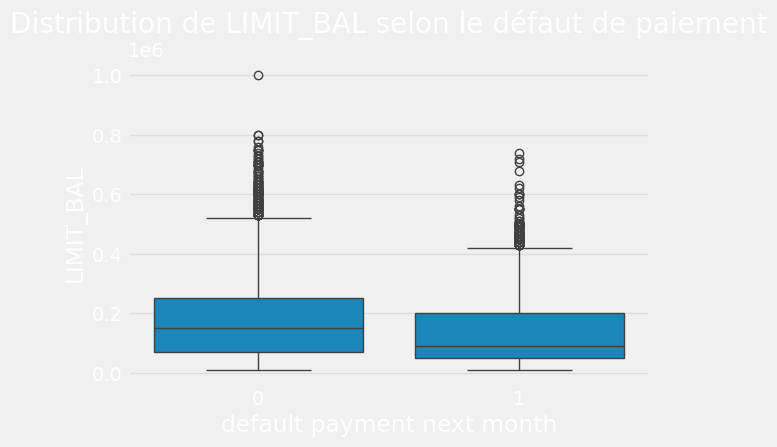

In [62]:
var_numeric = ['PAY_AMT1','PAY_AMT6','LIMIT_BAL']
for col in var_numeric: 
    plt.figure(figsize=(6,4))
    sns.boxplot(x="default payment next month",y=col,data=df)
    plt.title(f"Distribution de {col} selon le défaut de paiement")

Les distributions de PAY_AMT1 et PAY_AMT6 affichent un comportement très similaire. Pour les deux classes (0 et 1), la grande majorité des paiements est concentrée près de zéro, ce qui rend les boîtes très écrasées. Cependant, on observe une présence beaucoup plus importante de valeurs aberrantes (les points individuels très hauts) chez les clients qui ne font pas défaut (classe 0). Cela indique que les clients qui effectuent de très gros paiements ponctuels basculent statistiquement beaucoup moins en défaut de paiement.

Le graphique montre que les clients qui ne font pas défaut (classe 0) ont globalement une limite de crédit plus élevée que ceux en défaut de paiement (classe 1). La boîte de la classe 0 est positionnée plus haut, avec une médiane proche de 150 000 NT$, tandis que celle de la classe 1 se situe en dessous de 100 000 NT$. Cela confirme l'existence d'une relation négative : les profils jugés plus risqués reçoivent des limites de crédit plus faibles de la part de la banque.

Visualisation variables catégorielles vs cible

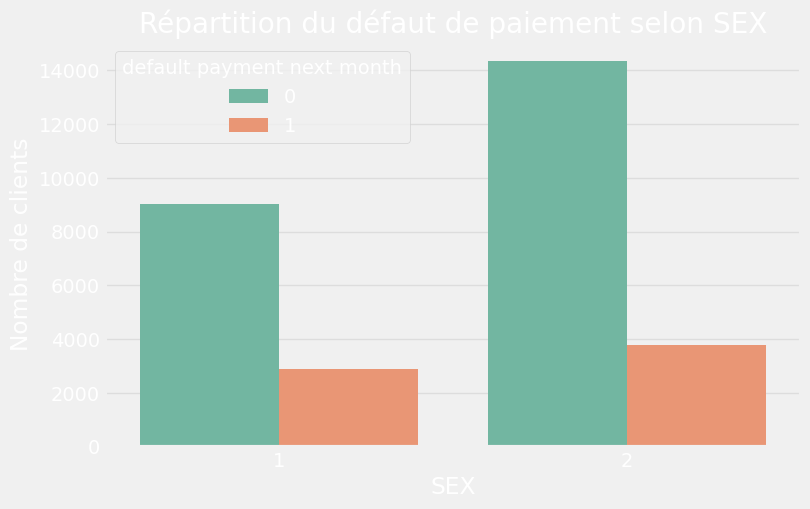

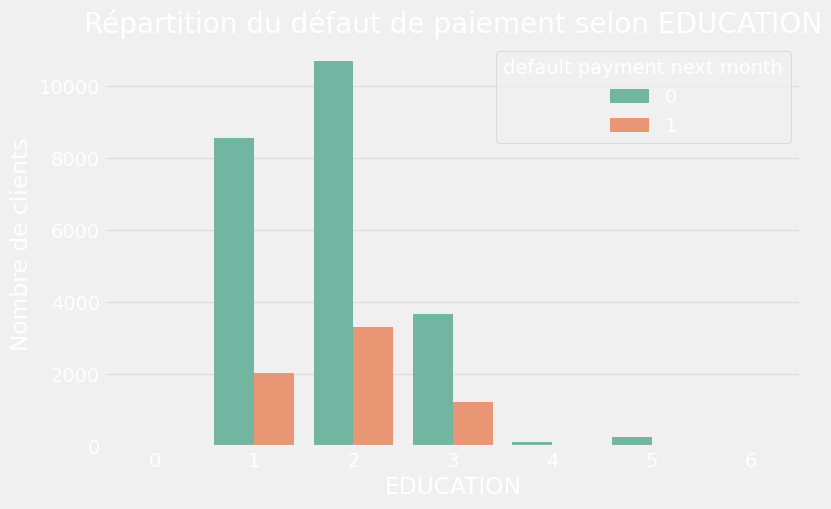

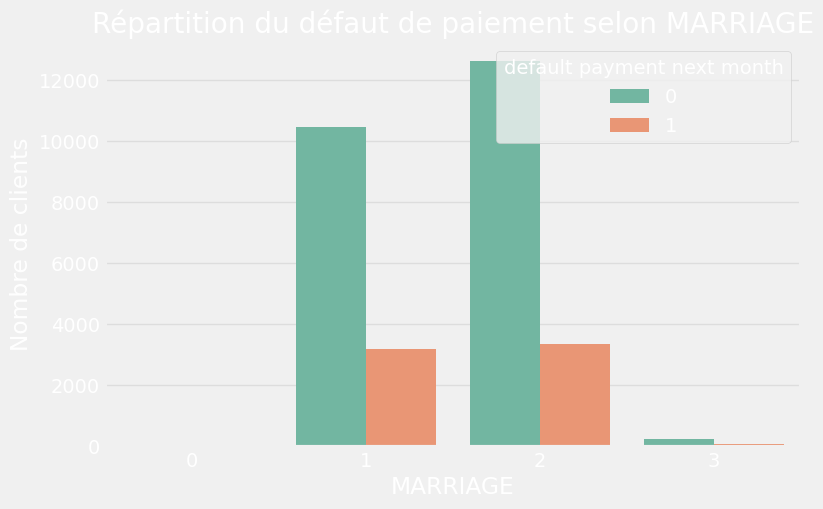

In [63]:
var_cat = ['SEX', 'EDUCATION', 'MARRIAGE']

for col in var_cat:
    plt.figure(figsize=(8, 5))
    # Le paramètre 'hue' permet de ventiler chaque catégorie selon la cible (0 ou 1)
    sns.countplot(x=col, hue='default payment next month', data=df, palette='Set2')
    plt.title(f"Répartition du défaut de paiement selon {col}")
    plt.ylabel("Nombre de clients")


Commentaire

L'analyse des proportions montre que le risque de défaut de paiement varie selon le profil des clients, même si les volumes globaux peuvent être trompeurs. On observe que les hommes (SEX = 1) présentent un taux de défaut légèrement plus élevé que les femmes, avec environ 25% de clients en échec contre 22%. Du côté de la situation matrimoniale, les personnes mariées (MARRIAGE = 1) affichent également une proportion de défaut légèrement supérieure à celle des célibataires. Enfin, concernant le niveau d'études (EDUCATION), ce sont les clients ayant un niveau d'études secondaires (catégorie 3) qui présentent la part de défaut de paiement la plus importante par rapport à leur effectif total.

Pré Traitement

ID                            0.0
LIMIT_BAL                     0.0
SEX                           0.0
EDUCATION                     0.0
MARRIAGE                      0.0
AGE                           0.0
PAY_0                         0.0
PAY_2                         0.0
PAY_3                         0.0
PAY_4                         0.0
PAY_5                         0.0
PAY_6                         0.0
BILL_AMT1                     0.0
BILL_AMT2                     0.0
BILL_AMT3                     0.0
BILL_AMT4                     0.0
BILL_AMT5                     0.0
BILL_AMT6                     0.0
PAY_AMT1                      0.0
PAY_AMT2                      0.0
PAY_AMT3                      0.0
PAY_AMT4                      0.0
PAY_AMT5                      0.0
PAY_AMT6                      0.0
default payment next month    0.0
dtype: float64


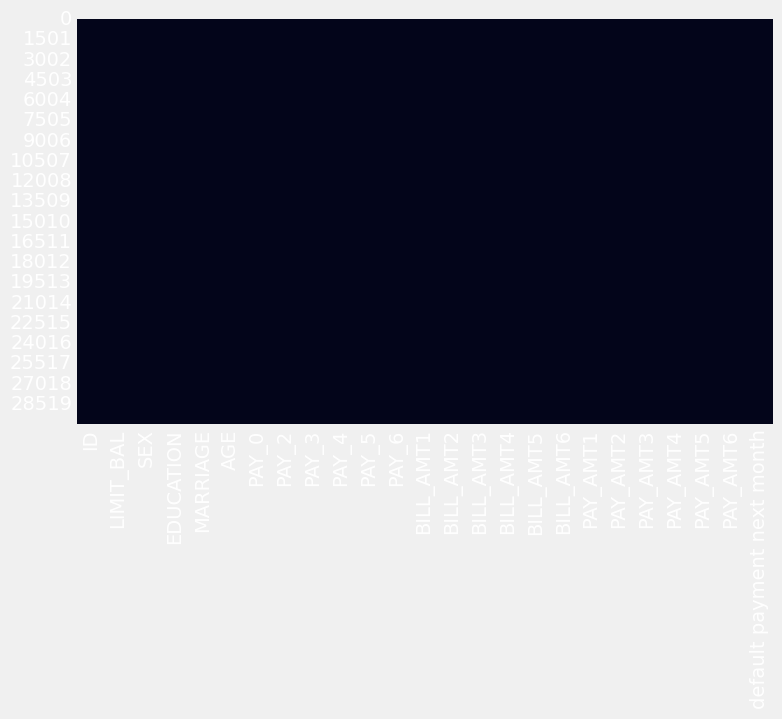

In [64]:
missing_data = df.isna()
sns.heatmap(missing_data,cbar=False)
# Pourcentage des valeurs manquantes
miss_rates = (missing_data.sum() /df.shape[0])*100
# Trie dans l'ordre croissant
miss_rates = miss_rates.sort_values(ascending=True)
print(miss_rates)

Comme souligné dans la description du problème, il n'y a aucune donnée manquante. 

In [65]:
data_clean = df.drop('ID',axis=1)
data_clean.head(3)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


Traitement des variables catégorielles

In [ ]:
var_cat = ['SEX', 'EDUCATION', 'MARRIAGE']

# On crée le préprocesseur qui sera intégré dans votre pipeline final
preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first'), var_cat), # 'drop=first' évite la redondance mathématique
    remainder='passthrough'                 # Garde les variables numériques inchangées
)

Traitement des variables numériques / quantitatives

Pour les variables PAY_0 à PAY_6, nous choisissons de les traiter comme des variables numériques ordonnées. Comme il y a une notion d'intensité dans le retard de paiement (plus le chiffre est grand, plus le retard est important), nous allons simplement les normaliser à l'aide d'un StandardScaler dans notre pipeline, à l'exception du cas où nous testerions une régression logistique, pour laquelle un OneHotEncoder pourrait être testé afin de mieux séparer les codes négatifs (-1, -2).

## Modélisation : AdaBoost

AdaBoost est une méthode d'ensemble **séquentielle (boosting)** : on entraîne plusieurs modèles faibles (des arbres de décision très courts) les uns après les autres, chacun se concentrant sur les observations mal classées par son prédécesseur. La prédiction finale est un vote pondéré de tous les arbres.

Contrairement à la régression logistique, les arbres n'ont pas besoin de normalisation : on réutilise donc `build_tree_preprocessor()` (encodage des variables catégorielles uniquement, le reste en passthrough).

In [ ]:
import os, sys

# Le package src/ est à la racine du projet. Il faut le rendre importable, que le
# kernel tourne en local (notebook lancé depuis notebook/) ou sur Google Colab
# (machine distante qui n'a pas les fichiers du projet).
try:
    import google.colab          # ce module n'existe que sur Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.isdir('src'):
    # Sur Colab : on clone la branche de travail pour récupérer le dossier src/
    if not os.path.isdir('Projet-AI28'):
        os.system('git clone -q -b Armand-branch-preprocessing '
                  'https://github.com/NdeyeAminataAida/Projet-AI28.git')
    sys.path.insert(0, os.path.abspath('Projet-AI28'))

# En local : ajoute la racine du projet au sys.path (parent de notebook/)
_cwd = os.getcwd()
PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebook' else _cwd
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import des fonctions de modélisation et d'évaluation
from sklearn.model_selection import train_test_split
from src.modeling import build_adaboost_model
from src.evaluation import train_and_evaluate

# Séparation variables explicatives / cible (on travaille sur data_clean, sans l'ID)
X = data_clean.drop('default payment next month', axis=1)
y = data_clean['default payment next month']

# Séparation train / test
# stratify=y conserve la proportion de défauts (~22%) dans les deux échantillons
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Construction du modèle AdaBoost (100 arbres faibles) et évaluation
# train_and_evaluate entraîne le modèle puis affiche le classification_report sur train et test
ada_model = build_adaboost_model(n_estimators=100)
ada_model = train_and_evaluate(ada_model, X_train, y_train, X_test, y_test)

### Matrice de confusion (modèle de base)

Le `classification_report` donne les scores chiffrés ; la matrice de confusion permet de visualiser directement les erreurs : faux positifs (clients sans défaut prédits en défaut) et surtout faux négatifs (défauts non détectés), qui sont les plus coûteux pour la banque.

In [ ]:
# Matrice de confusion sur le test set (ConfusionMatrixDisplay déjà importé plus haut)
ConfusionMatrixDisplay.from_estimator(ada_model, X_test, y_test, cmap='Blues')
plt.title("Matrice de confusion - AdaBoost (modèle de base)")
plt.show()

### Gestion du déséquilibre des classes

Le modèle de base atteint une bonne accuracy (~0.82) mais un **recall faible sur la classe "défaut" (~0.33)** : il rate les deux tiers des clients qui font réellement défaut, car la classe minoritaire (~22%) pèse peu dans l'apprentissage.

Pour corriger cela, on relance AdaBoost avec `class_weight='balanced'` sur l'arbre faible : les classes sont pondérées à l'inverse de leur fréquence, ce qui force le modèle à prêter plus d'attention aux défauts. On observe alors un **meilleur recall sur la classe 1**, au prix d'une précision et d'une accuracy globale plus faibles (compromis precision/recall).

In [ ]:
# AdaBoost avec pondération des classes pour traiter le déséquilibre
ada_balanced = build_adaboost_model(n_estimators=100, class_weight='balanced')
ada_balanced = train_and_evaluate(ada_balanced, X_train, y_train, X_test, y_test)

# Matrice de confusion du modèle pondéré (à comparer avec celle du modèle de base)
ConfusionMatrixDisplay.from_estimator(ada_balanced, X_test, y_test, cmap='Blues')
plt.title("Matrice de confusion - AdaBoost (class_weight='balanced')")
plt.show()